# Reward ablation study — Unitree quadruped, omnidirectional jumps on flat terrain

Each policy was evaluated on an **independently sampled random set of commanded targets**, so there
is no correspondence between sample *i* of one run and sample *i* of another. Comparing them
sample-by-sample (or comparing raw pooled means) is invalid: any difference in how the random
targets happened to land in the workspace shows up as a fake performance difference, and splitting
on the baseline's target distance produces a pure regression-to-the-mean artifact.

**This notebook fixes that by pairing regions of the command space instead of samples.**

1. Build one partition of the commanded-target space shared by all runs (grid, polar, or KMeans).
2. Inside each cell, every run has its own independent sample of targets — enough of them to
   estimate that run's local performance.
3. Compare policies **cell by cell**. The cell is the unit of pairing, so Wilcoxon signed-rank,
   difference maps and distance trends are all well defined again.
4. Aggregate with a **stratified estimator** (each cell weighted equally), which removes the
   confound from the runs having sampled the workspace differently.

Uncertainty uses a **cluster bootstrap** over cells, so it accounts for both the noise within a cell
and the variation between regions of the workspace.

## 1. Setup

In [30]:
import os
import os.path as osp
import warnings
from itertools import product

import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 500,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.axisbelow": True,
    "legend.frameon": False,
})

In [31]:
robot = "go1"

cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../../../logs/rsl_rl/unitree_{robot}_jump/ablation"))
# data_path = "/absolute/path/to/ablation"     # <-- override here if the relative path is wrong

print("data path :", data_path)
print("exists    :", osp.isdir(data_path))

FIG_DIR = osp.join(data_path, "figures_ablation")
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE = "baseline"

EXPERIMENTS = {
    "baseline":                    ("Baseline",  "Full reward set"),
    "no_bounce_angular_touchdown": ("w/o TD",    "No touchdown ang.-vel. + bounce penalty"),
    "no_liftoof_disc_penalty":     ("w/o LO",    "No lift-off state penalty"),
    "no_uarm":                     ("w/o UARM",  "Trajectory segment disabled"),
}
COLORS = {
    "baseline":                    "#2c3e50",
    "no_bounce_angular_touchdown": "#e67e22",
    "no_liftoof_disc_penalty":     "#2980b9",
    "no_uarm":                     "#c0392b",
}
ABLATIONS = [k for k in EXPERIMENTS if k != BASELINE]

SUCC_TIGHT = 0.10     # [m]
SUCC_LOOSE = 0.20     # [m]
PEN_CAP    = 0.50     # [m] censoring cap for the selection-free error metric (see section 2)
SAVE_FIGS  = True


def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(FIG_DIR, f"{name}.{ext}"), bbox_inches="tight")

data path : /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation
exists    : True


## 2. Loading

### Three error metrics, on purpose

A failed jump has a landing error, but it is not a *tracking* error. How you handle failures changes
the conclusion, so the notebook carries three metrics and reports all of them:

| metric | definition | bias |
|---|---|---|
| `pos_err` | error over **successful** jumps only | **selection-biased**: a policy that fails on the hard targets looks more accurate on the ones that survive |
| `pos_err_all` | measured error over **all** jumps | unbiased, but a few catastrophic falls dominate the mean |
| `pos_err_pen` | error censored at `PEN_CAP`, failures set to `PEN_CAP` | selection-free and bounded — **use this as the headline accuracy number** |

Reporting only `pos_err` is what made the touchdown ablation look *more accurate* in the previous
run: it also failed 2.7x more often, and those failures were removed from its own average.

In [32]:
def _np(x):
    # torch tensor / list -> numpy
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def _load(path):
    if not osp.isfile(path):
        return None
    obj = joblib.load(path)
    if isinstance(obj, (list, tuple)):
        return [_np(o) for o in obj]
    return _np(obj)


def _as_error(raw):
    # accepts an error array directly, or a [desired, actual] pair
    if raw is None:
        return None
    if isinstance(raw, (list, tuple)):
        if len(raw) == 2 and np.shape(raw[0]) == np.shape(raw[1]):
            return np.asarray(raw[1], float) - np.asarray(raw[0], float)
        return np.asarray(raw, float)
    return np.asarray(raw, float)


def _mag(err, deg=False):
    # scalar magnitude per sample: |.| for 1-D, L2 norm over trailing axes otherwise
    if err is None:
        return None
    e = np.asarray(err, float)
    if e.ndim == 0:
        return None
    m = np.abs(e) if e.ndim == 1 else np.linalg.norm(e.reshape(len(e), -1), axis=1)
    return np.degrees(m) if deg else m


def styled_boxplot(ax, data, labels, colors, **kw):
    kwargs = dict(showfliers=False, patch_artist=True,
                  medianprops=dict(color="black", lw=1.4))
    kwargs.update(kw)
    try:
        bp = ax.boxplot(data, tick_labels=labels, **kwargs)
    except TypeError:
        bp = ax.boxplot(data, labels=labels, **kwargs)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    return bp


def ecdf(ax, v, w=None, **kw):
    v = np.asarray(v, float)
    o = np.argsort(v)
    v = v[o]
    w = np.ones_like(v) if w is None else np.asarray(w, float)[o]
    ax.step(v, np.cumsum(w) / w.sum(), where="post", **kw)


def as_markdown(df, floatfmt=".3f"):
    try:
        return df.to_markdown(index=False, floatfmt=floatfmt)
    except ImportError:
        return df.to_string(index=False)

In [33]:
class DataExp:
    FILES = {
        "pos":        "pos_err.bin",
        "orient_err": "orient_err.bin",
        "fail":       "failed.bin",
        "bounce":     "bounce_err.bin",
        "lo_pos":     "lo_pos_err.bin",
        "lo_orient":  "lo_orient_err.bin",
        "lo_vel":     "lo_vel_err.bin",
        "lo_ang_vel": "lo_ang_vel_err.bin",
    }

    def __init__(self, data_path, name):
        self.name = name
        self.exp_path = osp.join(data_path, name)
        self.label, self.long_label = EXPERIMENTS.get(name, (name, name))
        self.color = COLORS.get(name, "#555555")
        self.cell = None                        # filled in section 3

    def load(self):
        self.raw = {k: _load(osp.join(self.exp_path, f)) for k, f in self.FILES.items()}
        miss = [k for k, v in self.raw.items() if v is None]
        if miss:
            print(f"[{self.name}] missing: {', '.join(miss)}")
        return self

    def shapes(self):
        rows = []
        for k, v in self.raw.items():
            if v is None:
                rows.append((self.name, k, "MISSING", ""))
            elif isinstance(v, list):
                rows.append((self.name, k, f"list[{len(v)}]",
                             " | ".join(str(np.shape(a)) for a in v)))
            else:
                rows.append((self.name, k, str(v.dtype), str(v.shape)))
        return pd.DataFrame(rows, columns=["exp", "field", "kind", "shape"])

    def process(self):
        pos = self.raw["pos"]
        des = np.asarray(pos[0], float)
        act = np.asarray(pos[1], float)

        self.des_pos    = des[:, :2]
        self.actual_pos = act[:, :2]
        self.n          = len(des)

        self.pos_err = np.linalg.norm(self.des_pos - self.actual_pos, axis=1)

        f = self.raw["fail"]
        self.fail = np.zeros(self.n, bool) if f is None else np.asarray(f).reshape(-1).astype(bool)
        self.ok = ~self.fail

        # three accuracy variants (see the markdown above)
        self.pos_err_all = self.pos_err.copy()
        self.pos_err_pen = np.where(self.fail, PEN_CAP, np.minimum(self.pos_err, PEN_CAP))

        oe = _as_error(self.raw["orient_err"])
        if oe is not None and oe.ndim == 2 and oe.shape[1] >= 3:
            self.yaw_err = np.degrees(np.abs(oe[:, 2]))
        else:
            self.yaw_err = _mag(oe, deg=True)

        self.bounce     = _mag(_as_error(self.raw["bounce"]))
        self.lo_pos     = _mag(_as_error(self.raw["lo_pos"]))
        self.lo_orient  = _mag(_as_error(self.raw["lo_orient"]), deg=True)
        self.lo_vel     = _mag(_as_error(self.raw["lo_vel"]))
        self.lo_ang_vel = _mag(_as_error(self.raw["lo_ang_vel"]))

        self.des_dist    = np.linalg.norm(self.des_pos, axis=1)
        self.actual_dist = np.linalg.norm(self.actual_pos, axis=1)
        self.des_angle   = np.arctan2(self.des_pos[:, 1], self.des_pos[:, 0])
        self.is_front    = self.des_pos[:, 0] >= 0

        self.succ_tight = self.ok & (self.pos_err <= SUCC_TIGHT)
        self.succ_loose = self.ok & (self.pos_err <= SUCC_LOOSE)
        return self


# attribute -> (pretty name, unit, per-sample restricted to successes?)
METRICS = {
    "pos_err_pen": ("Landing error (censored)",  "m",     False),
    "pos_err":     ("Landing error | success",   "m",     True),
    "pos_err_all": ("Landing error (all jumps)", "m",     False),
    "fail":        ("Failure rate",              "%",     False),
    "succ_loose":  (f"Success @ {SUCC_LOOSE} m", "%",     False),
    "succ_tight":  (f"Success @ {SUCC_TIGHT} m", "%",     False),
    "yaw_err":     ("Yaw error",                 "deg",   True),
    "bounce":      ("Bounce (touchdown->rest)",  "m",     True),
    "lo_pos":      ("Lift-off position error",   "m",     True),
    "lo_orient":   ("Lift-off orientation err",  "deg",   True),
    "lo_vel":      ("Lift-off lin. vel. error",  "m/s",   True),
    "lo_ang_vel":  ("Lift-off ang. vel. error",  "rad/s", True),
}
PCT_METRICS = {"fail", "succ_loose", "succ_tight"}
MNAME = {k: v[0] for k, v in METRICS.items()}
MUNIT = {k: v[1] for k, v in METRICS.items()}


def mlabel(k):
    return f"{MNAME.get(k, k)} [{MUNIT.get(k, '-')}]"

In [34]:
exps = {}
for name in EXPERIMENTS:
    e = DataExp(data_path, name)
    if not osp.isdir(e.exp_path):
        print(f"[skip] folder not found: {e.exp_path}")
        continue
    exps[name] = e.load().process()

base = exps[BASELINE]
abl_present = [n for n in ABLATIONS if n in exps]
print("\nloaded:", list(exps))
print("samples per run:", {e.label: e.n for e in exps.values()})

pd.concat([e.shapes() for e in exps.values()], ignore_index=True) \
  .pivot(index="field", columns="exp", values="shape")


loaded: ['baseline', 'no_bounce_angular_touchdown', 'no_liftoof_disc_penalty', 'no_uarm']
samples per run: {'Baseline': 4096, 'w/o TD': 4096, 'w/o LO': 4096, 'w/o UARM': 4096}


exp,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
field,,,,
bounce,"(4096,)","(4096,)","(4096,)","(4096,)"
fail,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_ang_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_orient,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_pos,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
orient_err,"(4096, 3)","(4096, 3)","(4096, 3)","(4096, 3)"
pos,"(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)"


In [35]:
# how different were the random target sets? this is the confound we are removing
rows = []
for n, e in exps.items():
    rows.append({
        "Policy": e.label, "N": e.n,
        "mean |target| [m]": e.des_dist.mean(),
        "p90 |target| [m]":  np.percentile(e.des_dist, 90),
        "frac forward":      e.is_front.mean(),
        "mean |y| [m]":      np.abs(e.des_pos[:, 1]).mean(),
    })
cmd_df = pd.DataFrame(rows).set_index("Policy")
print("Commanded-target distribution per run (should be similar, but is not identical):")
cmd_df.round(4)

Commanded-target distribution per run (should be similar, but is not identical):


,N,mean |target| [m],p90 |target| [m],frac forward,mean |y| [m]
Policy,,,,,
Baseline,4096,0.6274,1.0722,0.6672,0.3002
w/o TD,4096,0.6252,1.0665,0.6575,0.2994
w/o LO,4096,0.6187,1.0570,0.6599,0.3007
w/o UARM,4096,0.6266,1.0651,0.6560,0.3023


## 3. Shared partition of the command space

`PARTITION_KIND` options:

* **`"grid"`** — regular cartesian grid over the target bounding box. Most interpretable, and lets
  the difference maps be drawn as a proper heat map. Default.
* **`"polar"`** — bins in (distance, direction), with equal-count distance rings. The most natural
  geometry for jumping: performance varies with how far and which way, not with x and y separately.
* **`"kmeans"`** — data-adaptive clusters fitted on the pooled targets of all runs. Use if the
  targets are not sampled over a rectangle.

Pick the number of cells to get **~50–150 samples per run per cell**. Too few cells and you average
away real spatial structure; too many and each cell estimate is noise. With ~4000 samples per run,
48–64 cells is about right.

In [36]:
PARTITION_KIND = "grid"      # "grid" | "polar" | "kmeans"
GRID_NX, GRID_NY = 15, 10      # for "grid"
POLAR_NR, POLAR_NA = 5, 10   # for "polar"
N_CLUSTERS = 48              # for "kmeans"
MIN_PER_CELL = 10            # a cell is usable only if EVERY run has at least this many samples


class Partition:
    def __init__(self, xy_all, kind="grid", **kw):
        self.kind = kind
        self.xy_all = np.asarray(xy_all, float)
        getattr(self, f"_fit_{kind}")(**kw)

    # ---------------------------------------------------------------- grid
    def _fit_grid(self, nx=8, ny=6):
        x, y = self.xy_all[:, 0], self.xy_all[:, 1]
        self.xe = np.linspace(x.min(), x.max() + 1e-9, nx + 1)
        self.ye = np.linspace(y.min(), y.max() + 1e-9, ny + 1)
        self.nx, self.ny = nx, ny
        self.n_cells = nx * ny
        cx = 0.5 * (self.xe[:-1] + self.xe[1:])
        cy = 0.5 * (self.ye[:-1] + self.ye[1:])
        self.centroids = np.array([[cx[i], cy[j]] for i, j in product(range(nx), range(ny))])

    def _assign_grid(self, xy):
        ix = np.clip(np.digitize(xy[:, 0], self.xe) - 1, 0, self.nx - 1)
        iy = np.clip(np.digitize(xy[:, 1], self.ye) - 1, 0, self.ny - 1)
        return ix * self.ny + iy

    # --------------------------------------------------------------- polar
    def _fit_polar(self, nr=5, na=10):
        r = np.linalg.norm(self.xy_all, axis=1)
        self.re = np.quantile(r, np.linspace(0, 1, nr + 1))     # equal-count rings
        self.re[0], self.re[-1] = 0.0, self.re[-1] + 1e-9
        self.ae = np.linspace(-np.pi, np.pi + 1e-9, na + 1)
        self.nr, self.na = nr, na
        self.n_cells = nr * na
        rc = 0.5 * (self.re[:-1] + self.re[1:])
        ac = 0.5 * (self.ae[:-1] + self.ae[1:])
        self.centroids = np.array([[rc[i] * np.cos(ac[j]), rc[i] * np.sin(ac[j])]
                                   for i, j in product(range(nr), range(na))])

    def _assign_polar(self, xy):
        r = np.linalg.norm(xy, axis=1)
        a = np.arctan2(xy[:, 1], xy[:, 0])
        ir = np.clip(np.digitize(r, self.re) - 1, 0, self.nr - 1)
        ia = np.clip(np.digitize(a, self.ae) - 1, 0, self.na - 1)
        return ir * self.na + ia

    # -------------------------------------------------------------- kmeans
    def _fit_kmeans(self, n_clusters=48, seed=0):
        from sklearn.cluster import KMeans
        self.km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(self.xy_all)
        self.n_cells = n_clusters
        self.centroids = self.km.cluster_centers_

    def _assign_kmeans(self, xy):
        return self.km.predict(xy)

    # ------------------------------------------------------------ interface
    def assign(self, xy):
        return getattr(self, f"_assign_{self.kind}")(np.asarray(xy, float)).astype(int)

    def plot(self, ax, values, **kw):
        v = np.asarray(values, float)
        if self.kind == "grid":
            grid = np.full((self.nx, self.ny), np.nan)
            for c in range(self.n_cells):
                grid[c // self.ny, c % self.ny] = v[c]
            return ax.pcolormesh(self.xe, self.ye, grid.T, shading="flat", **kw)
        good = np.isfinite(v)
        return ax.scatter(self.centroids[good, 0], self.centroids[good, 1],
                          c=v[good], s=90, marker="s" if self.kind == "polar" else "o", **kw)


kw = dict(grid=dict(nx=GRID_NX, ny=GRID_NY),
          polar=dict(nr=POLAR_NR, na=POLAR_NA),
          kmeans=dict(n_clusters=N_CLUSTERS))[PARTITION_KIND]

part = Partition(np.vstack([e.des_pos for e in exps.values()]), kind=PARTITION_KIND, **kw)
for e in exps.values():
    e.cell = part.assign(e.des_pos)

counts = pd.DataFrame({e.label: np.bincount(e.cell, minlength=part.n_cells)
                       for e in exps.values()})
VALID = (counts >= MIN_PER_CELL).all(axis=1).values
valid_cells = np.nonzero(VALID)[0]

print(f"partition        : {PARTITION_KIND}, {part.n_cells} cells")
print(f"usable cells     : {VALID.sum()} / {part.n_cells}  (>= {MIN_PER_CELL} samples in every run)")
print(f"samples per cell : min {counts.values.min()}, median {int(np.median(counts.values))}, "
      f"max {counts.values.max()}")
cov = counts[VALID].sum().sum() / counts.sum().sum()
print(f"coverage         : {100*cov:.1f}% of all samples fall in usable cells")

partition        : grid, 150 cells
usable cells     : 150 / 150  (>= 10 samples in every run)
samples per cell : min 13, median 27, max 43
coverage         : 100.0% of all samples fall in usable cells


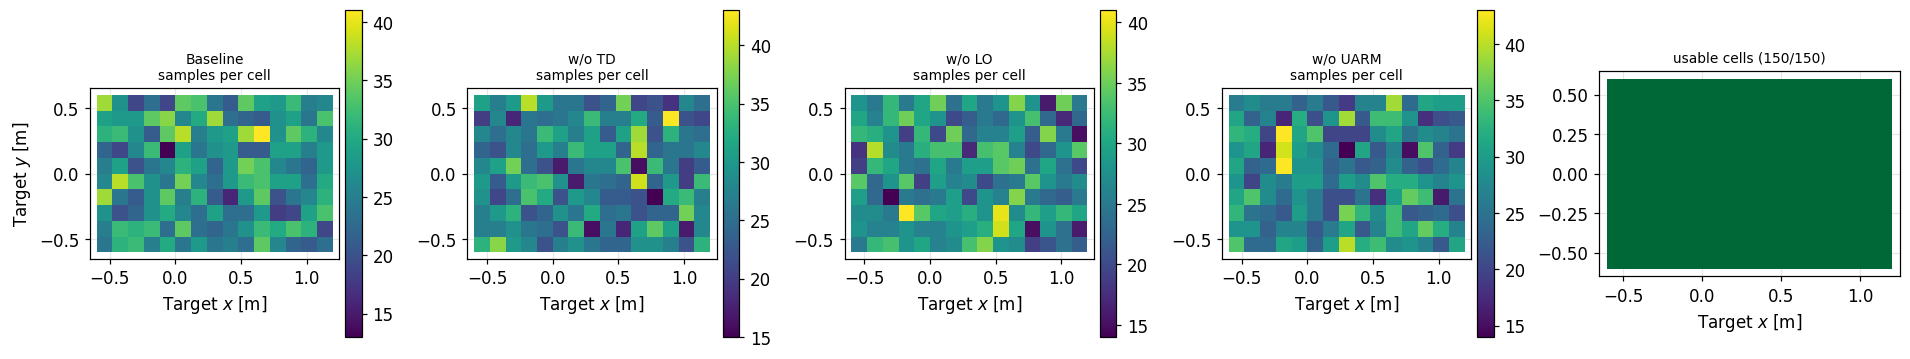

In [37]:
# sanity figure: occupancy per run + which cells are usable
fig, axes = plt.subplots(1, len(exps) + 1, figsize=(3.5 * (len(exps) + 1), 3.4))
XLIM = (part.xy_all[:, 0].min() - 0.05, part.xy_all[:, 0].max() + 0.05)
YLIM = (part.xy_all[:, 1].min() - 0.05, part.xy_all[:, 1].max() + 0.05)

for ax, (n, e) in zip(axes, exps.items()):
    m = part.plot(ax, np.bincount(e.cell, minlength=part.n_cells).astype(float), cmap="viridis")
    fig.colorbar(m, ax=ax, pad=0.02)
    ax.set_title(f"{e.label}\nsamples per cell", fontsize=9)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
axes[0].set_ylabel("Target $y$ [m]")

ax = axes[-1]
part.plot(ax, VALID.astype(float), cmap="RdYlGn", vmin=0, vmax=1)
ax.set_title(f"usable cells ({VALID.sum()}/{part.n_cells})", fontsize=9)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
ax.set_xlabel("Target $x$ [m]")
fig.tight_layout()
savefig(fig, "partition_coverage")
plt.show()

## 4. Cell-level statistics

For every (cell, policy) pair we compute a local estimate of each metric. This table is the
foundation for everything below.

In [38]:
def cell_values(e, attr):
    # per-cell estimate of one metric for one run
    v = getattr(e, attr, None)
    if v is None:
        return np.full(part.n_cells, np.nan)
    v = np.asarray(v, float)
    restrict_ok = METRICS.get(attr, (None, None, False))[2]
    out = np.full(part.n_cells, np.nan)
    for c in range(part.n_cells):
        m = e.cell == c
        if restrict_ok:
            m = m & e.ok
        if m.sum() >= 3:
            out[c] = np.nanmean(v[m])
    if attr in PCT_METRICS:
        out = 100.0 * out
    return out


CELL = {attr: pd.DataFrame({n: cell_values(e, attr) for n, e in exps.items()})
        for attr in METRICS}

# also keep per-cell medians of the primary metric (robust to the heavy tail)
CELL["pos_err_pen_med"] = pd.DataFrame({
    n: [np.median(e.pos_err_pen[e.cell == c]) if (e.cell == c).sum() >= 3 else np.nan
        for c in range(part.n_cells)]
    for n, e in exps.items()})

print("cell tables built for:", list(CELL))
CELL["pos_err_pen"].loc[valid_cells].describe().round(4)

cell tables built for: ['pos_err_pen', 'pos_err', 'pos_err_all', 'fail', 'succ_loose', 'succ_tight', 'yaw_err', 'bounce', 'lo_pos', 'lo_orient', 'lo_vel', 'lo_ang_vel', 'pos_err_pen_med']


,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
count,150.0000,150.0000,150.0000,150.0000
mean,0.0796,0.0876,0.1017,0.0892
std,0.1145,0.1282,0.1330,0.1178
min,0.0048,0.0046,0.0042,0.0064
25%,0.0119,0.0121,0.0155,0.0151
50%,0.0224,0.0196,0.0323,0.0301
75%,0.0937,0.1024,0.1448,0.1101
max,0.4855,0.5000,0.5000,0.4853


### 4.1 Stratified vs naive aggregates

The **naive** number pools all samples of a run — it inherits that run's particular random target
draw. The **stratified** number averages the per-cell values over usable cells, so every region of
the workspace counts equally in every policy. Where the two disagree, the naive number is
partly measuring the target sampling, not the policy.

In [39]:
def strat(attr, policy):
    return float(np.nanmean(CELL[attr].loc[valid_cells, policy]))


def naive(attr, e):
    v = getattr(e, attr, None)
    if v is None:
        return np.nan
    v = np.asarray(v, float)
    if METRICS.get(attr, (None, None, False))[2]:
        v = v[e.ok]
    return float(100 * np.nanmean(v) if attr in PCT_METRICS else np.nanmean(v))


rows = []
for n, e in exps.items():
    r = {"Policy": e.label}
    for attr in METRICS:
        r[mlabel(attr)] = strat(attr, n)
    r["Landing err median [m]"] = float(np.nanmean(CELL["pos_err_pen_med"].loc[valid_cells, n]))
    rows.append(r)
summary = pd.DataFrame(rows)

comp = pd.DataFrame({
    "naive pooled":  {e.label: naive("pos_err_pen", e) for e in exps.values()},
    "stratified":    {e.label: strat("pos_err_pen", n) for n, e in exps.items()},
})
comp["difference"] = comp["stratified"] - comp["naive pooled"]
print("Censored landing error [m] — naive vs stratified")
display(comp.round(4))

summary.set_index("Policy").T.round(4)

Censored landing error [m] — naive vs stratified


,naive pooled,stratified,difference
Baseline,0.0790,0.0796,0.0007
w/o TD,0.0859,0.0876,0.0017
w/o LO,0.0956,0.1017,0.0061
w/o UARM,0.0886,0.0892,0.0006


Policy,Baseline,w/o TD,w/o LO,w/o UARM
Landing error (censored) [m],0.0796,0.0876,0.1017,0.0892
Landing error | success [m],0.0734,0.0688,0.1024,0.0773
Landing error (all jumps) [m],0.0740,0.0702,0.1024,0.0781
Failure rate [%],1.5343,4.4111,0.0000,3.0294
Success @ 0.2 m [%],85.6749,84.1185,80.7469,84.4802
Success @ 0.1 m [%],76.2817,75.6241,69.4236,74.4326
Yaw error [deg],3.7175,4.5022,2.9221,2.8169
Bounce (touchdown->rest) [m],0.1579,0.1689,0.1422,0.1598
Lift-off position error [m],0.0209,0.0214,0.0262,0.0170
Lift-off orientation err [deg],2.2979,2.7163,3.0718,2.1423


## 5. Cell-paired comparison against the baseline

Cells are the paired unit. For each ablation and metric:

* **stratified difference** = mean over cells of (ablation − baseline), with a **cluster-bootstrap**
  95% CI (resampling cells with replacement);
* **Wilcoxon signed-rank over cells** (n = number of usable cells, not number of jumps — so the
  p-values no longer become significant just because you evaluated 4000 targets);
* **cells worse** = fraction of the workspace where the ablation is worse, a directly interpretable
  effect measure;
* **stratified Cliff's δ** = Cliff's delta computed *within* each cell on the raw samples, then
  averaged — an effect size that is not confounded by the target distributions.

Everything is corrected for multiple comparisons with **Holm–Bonferroni** across the whole family.

In [40]:
def cluster_bootstrap_ci(dvals, n_boot=5000, alpha=0.05, seed=0):
    d = np.asarray(dvals, float)
    d = d[np.isfinite(d)]
    if len(d) < 3:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    s = np.nanmean(d[idx], axis=1)
    return float(np.percentile(s, 100 * alpha / 2)), float(np.percentile(s, 100 * (1 - alpha / 2)))


def cliffs_delta(a, b):
    # delta > 0  <=>  a tends to be larger than b
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    u = stats.mannwhitneyu(a, b, alternative="two-sided").statistic
    return float(2.0 * u / (len(a) * len(b)) - 1.0)


def strat_cliffs(abl, attr):
    # Cliff's delta computed inside each cell, then averaged over cells
    va = getattr(abl, attr, None)
    vb = getattr(base, attr, None)
    if va is None or vb is None:
        return np.nan
    va, vb = np.asarray(va, float), np.asarray(vb, float)
    restrict = METRICS.get(attr, (None, None, False))[2]
    ds = []
    for c in valid_cells:
        ma, mb = abl.cell == c, base.cell == c
        if restrict:
            ma, mb = ma & abl.ok, mb & base.ok
        if ma.sum() >= 5 and mb.sum() >= 5:
            ds.append(cliffs_delta(va[ma], vb[mb]))
    return float(np.nanmean(ds)) if ds else np.nan


def delta_label(d):
    if not np.isfinite(d):
        return "-"
    ad = abs(d)
    return ("negligible" if ad < 0.147 else "small" if ad < 0.33
            else "medium" if ad < 0.474 else "large")


def holm(pvals):
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    m = len(p)
    adj = np.empty(m)
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i])
        adj[i] = min(running, 1.0)
    return adj


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


def cell_compare(abl_name, attr):
    x = CELL[attr].loc[valid_cells, BASELINE].values
    y = CELL[attr].loc[valid_cells, abl_name].values
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 5:
        return None
    d = y - x
    lo, hi = cluster_bootstrap_ci(d)
    try:
        p = stats.wilcoxon(x, y).pvalue if np.any(d != 0) else 1.0
    except ValueError:
        p = 1.0
    cd = strat_cliffs(exps[abl_name], attr) if attr not in PCT_METRICS else np.nan
    return {
        "Ablation":   exps[abl_name].label,
        "Metric":     mlabel(attr),
        "attr":       attr,
        "cells":      int(len(x)),
        "baseline":   float(np.mean(x)),
        "ablation":   float(np.mean(y)),
        "diff":       float(np.mean(d)),
        "CI lo":      lo,
        "CI hi":      hi,
        "rel [%]":    float(100 * np.mean(d) / abs(np.mean(x))) if np.mean(x) != 0 else np.nan,
        "cells worse [%]": float(100 * np.mean(d > 0)),
        "p_raw":      float(p),
        "cliff d":    cd,
        "effect":     delta_label(cd),
    }


rows = []
for n in abl_present:
    for attr in METRICS:
        r = cell_compare(n, attr)
        if r is not None:
            rows.append(r)

stats_df = pd.DataFrame(rows)
stats_df["p_holm"] = holm(stats_df["p_raw"].values)
stats_df["sig"] = [stars(p) for p in stats_df["p_holm"]]
stats_df.to_csv(osp.join(FIG_DIR, "ablation_cell_stats.csv"), index=False)

show = ["Ablation", "Metric", "cells", "baseline", "ablation", "diff", "CI lo", "CI hi",
        "rel [%]", "cells worse [%]", "p_holm", "sig", "cliff d", "effect"]
stats_df[show].round(4)

/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Ablation,Metric,cells,baseline,ablation,diff,CI lo,CI hi,rel [%],cells worse [%],p_holm,sig,cliff d,effect
0,w/o TD,Landing error (censored) [m],150,0.0796,0.0876,0.0079,0.0008,0.0166,9.9535,42.6667,0.5853,n.s.,-0.0551,negligible
1,w/o TD,Landing error | success [m],147,0.0731,0.0688,-0.0043,-0.0067,-0.0018,-5.8453,38.0952,0.0040,**,-0.0879,negligible
2,w/o TD,Landing error (all jumps) [m],150,0.0740,0.0702,-0.0039,-0.0060,-0.0017,-5.2033,37.3333,0.0027,**,-0.0904,negligible
3,w/o TD,Failure rate [%],150,1.5343,4.4111,2.8768,1.1314,4.9993,187.5001,8.0000,0.0374,*,NaN,-
4,w/o TD,Success @ 0.2 m [%],150,85.6749,84.1185,-1.5564,-3.5584,0.2168,-1.8167,4.6667,0.5919,n.s.,NaN,-
5,w/o TD,Success @ 0.1 m [%],150,76.2817,75.6241,-0.6576,-2.2732,0.8991,-0.8621,8.0000,0.6614,n.s.,NaN,-
6,w/o TD,Yaw error [deg],147,3.6887,4.5022,0.8136,0.4604,1.1698,22.0559,69.3878,0.0000,***,0.2263,small
7,w/o TD,Bounce (touchdown->rest) [m],147,0.1546,0.1689,0.0143,0.0103,0.0180,9.2677,82.9932,0.0000,***,0.3953,medium
8,w/o TD,Lift-off position error [m],147,0.0206,0.0214,0.0008,0.0000,0.0016,3.8055,52.3810,0.5919,n.s.,0.0270,negligible
9,w/o TD,Lift-off orientation err [deg],147,2.2988,2.7163,0.4175,0.3456,0.4920,18.1615,84.3537,0.0000,***,0.5325,large


In [41]:
# headline table for the paper: the three metrics that matter, per ablation
head_attrs = ["pos_err_pen", "fail", "succ_loose"]
tbl = stats_df[stats_df["attr"].isin(head_attrs)][
    ["Ablation", "Metric", "baseline", "ablation", "diff", "CI lo", "CI hi",
     "cells worse [%]", "p_holm", "sig", "cliff d"]]
tex = tbl.to_latex(index=False, float_format="%.3f", escape=False)
with open(osp.join(FIG_DIR, "ablation_headline.tex"), "w") as fh:
    fh.write(tex)
tbl.round(4)

,Ablation,Metric,baseline,ablation,diff,CI lo,CI hi,cells worse [%],p_holm,sig,cliff d
0,w/o TD,Landing error (censored) [m],0.0796,0.0876,0.0079,0.0008,0.0166,42.6667,0.5853,n.s.,-0.0551
3,w/o TD,Failure rate [%],1.5343,4.4111,2.8768,1.1314,4.9993,8.0000,0.0374,*,NaN
4,w/o TD,Success @ 0.2 m [%],85.6749,84.1185,-1.5564,-3.5584,0.2168,4.6667,0.5919,n.s.,NaN
12,w/o LO,Landing error (censored) [m],0.0796,0.1017,0.0221,0.0151,0.0294,70.0000,0.0000,***,0.3310
15,w/o LO,Failure rate [%],1.5343,0.0000,-1.5343,-3.4702,-0.1056,0.0000,0.4311,n.s.,NaN
16,w/o LO,Success @ 0.2 m [%],85.6749,80.7469,-4.9280,-7.9569,-2.3760,2.0000,0.0040,**,NaN
24,w/o UARM,Landing error (censored) [m],0.0796,0.0892,0.0095,0.0044,0.0153,65.3333,0.0039,**,0.1754
27,w/o UARM,Failure rate [%],1.5343,3.0294,1.4951,0.4160,2.8750,6.0000,0.0963,n.s.,NaN
28,w/o UARM,Success @ 0.2 m [%],85.6749,84.4802,-1.1947,-2.8871,0.3674,8.0000,0.6614,n.s.,NaN


## 6. Where in the workspace does each term matter?

Cell-level difference maps. These replace the sample-level scatter maps, which were meaningless
once the targets stopped matching.

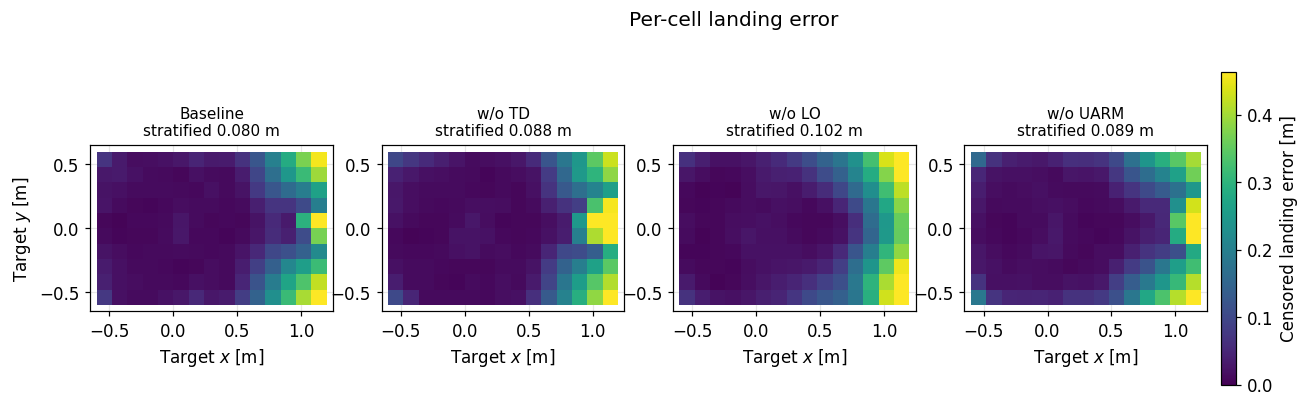

In [42]:
fig, axes = plt.subplots(1, len(exps), figsize=(3.9 * len(exps), 3.7))
vals = [CELL["pos_err_pen"][n].values for n in exps]
vmax = np.nanpercentile(np.concatenate(vals), 98)
for ax, (n, e) in zip(axes, exps.items()):
    v = CELL["pos_err_pen"][n].values.copy()
    v[~VALID] = np.nan
    m = part.plot(ax, v, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(f"{e.label}\nstratified {strat('pos_err_pen', n):.3f} m", fontsize=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
axes[0].set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m, ax=axes.tolist(), pad=0.01)
cb.set_label("Censored landing error [m]")
fig.suptitle("Per-cell landing error", y=1.03)
savefig(fig, "cellmap_error")
plt.show()

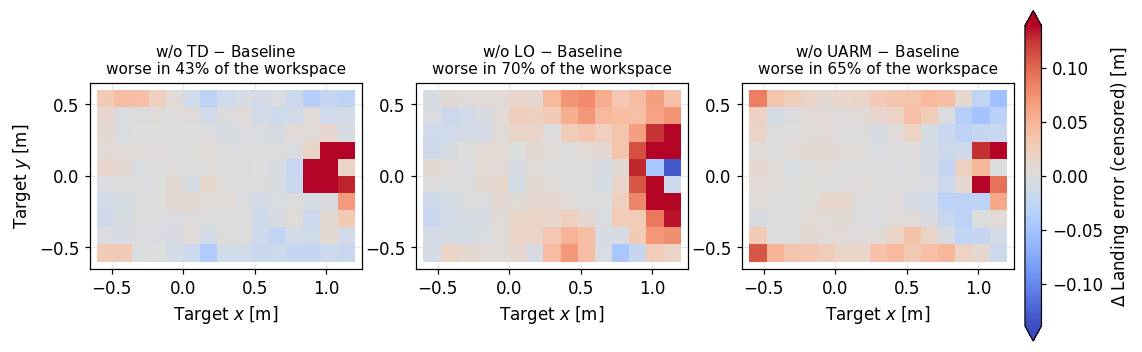

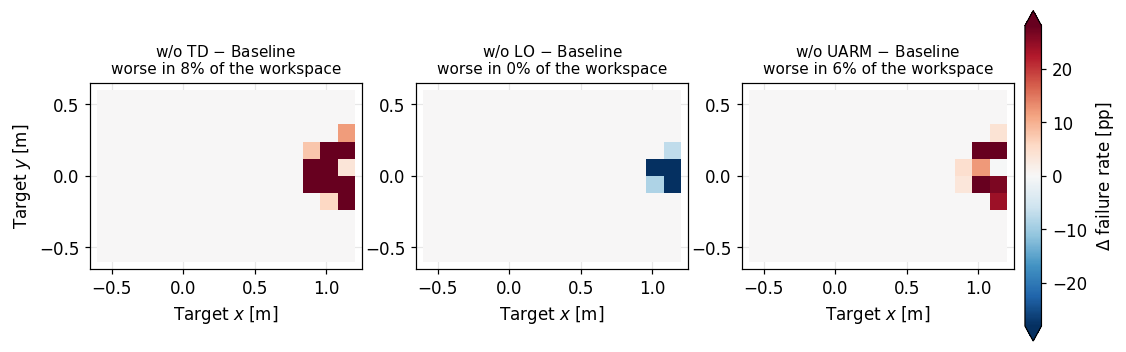

In [43]:
def delta_map_figure(attr, fname, cmap="coolwarm", label=None):
    d_all = [CELL[attr][n].values - CELL[attr][BASELINE].values for n in abl_present]
    lim = np.nanpercentile(np.abs(np.concatenate(d_all)), 97)
    if not np.isfinite(lim) or lim == 0:
        lim = 1e-3
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, axes = plt.subplots(1, len(abl_present), figsize=(4.3 * len(abl_present), 3.9))
    axes = np.atleast_1d(axes)
    for ax, n, d in zip(axes, abl_present, d_all):
        d = d.copy()
        d[~VALID] = np.nan
        m = part.plot(ax, d, cmap=cmap, norm=norm)
        worse = 100 * np.nanmean(d[valid_cells] > 0)
        ax.set_title(f"{exps[n].label} $-$ Baseline\nworse in {worse:.0f}% of the workspace",
                     fontsize=10)
        ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
        ax.set_xlabel("Target $x$ [m]")
    axes[0].set_ylabel("Target $y$ [m]")
    cb = fig.colorbar(m, ax=axes.tolist(), pad=0.01, extend="both")
    cb.set_label(label or f"$\\Delta$ {mlabel(attr)}")
    savefig(fig, fname)
    plt.show()


delta_map_figure("pos_err_pen", "cellmap_delta_error")
delta_map_figure("fail", "cellmap_delta_failure", cmap="RdBu_r",
                 label="$\\Delta$ failure rate [pp]")

## 7. Distance and direction dependence

Now computed **from the cells**, so there is no regression-to-the-mean artifact: each cell has its
own baseline and ablation estimate from independent samples of the same region.

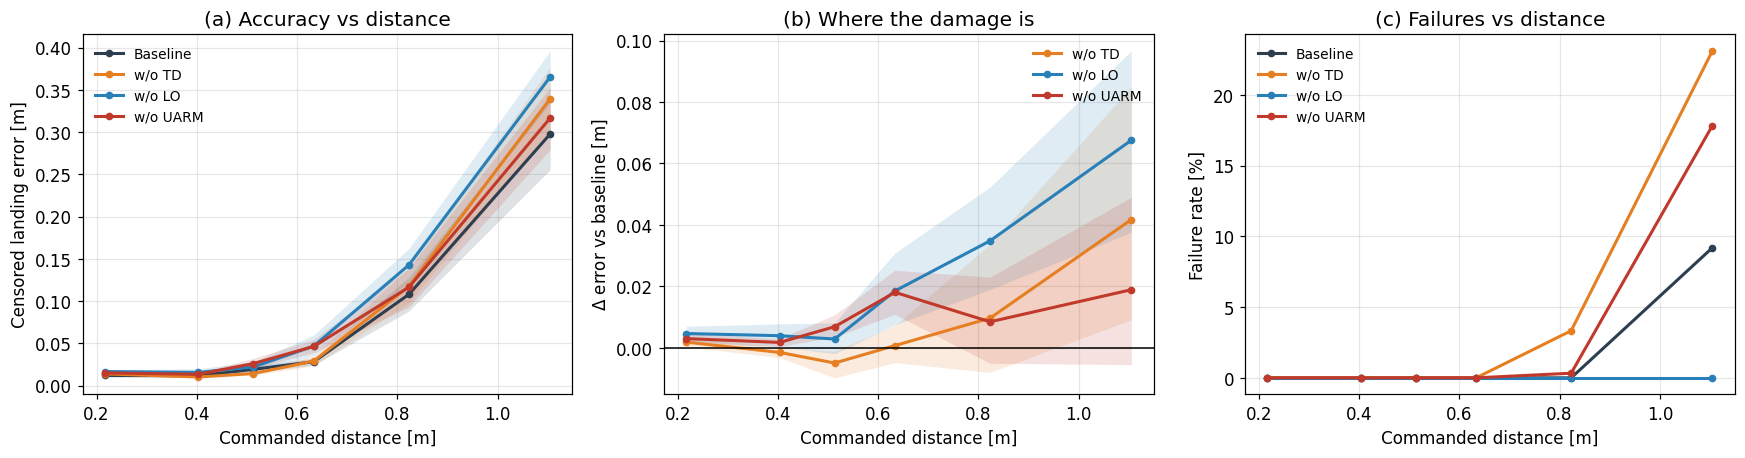

In [44]:
cdist = np.linalg.norm(part.centroids, axis=1)
cang = np.arctan2(part.centroids[:, 1], part.centroids[:, 0])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) error vs distance, per policy, from cell estimates
ax = axes[0]
r_edges = np.quantile(cdist[valid_cells], np.linspace(0, 1, 7))
r_c = 0.5 * (r_edges[:-1] + r_edges[1:])
for n, e in exps.items():
    v = CELL["pos_err_pen"][n].values
    ys, los, his = [], [], []
    for a, b in zip(r_edges[:-1], r_edges[1:]):
        sel = valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]
        vv = v[sel]
        ys.append(np.nanmean(vv))
        lo, hi = cluster_bootstrap_ci(vv, n_boot=2000)
        los.append(lo); his.append(hi)
    ax.plot(r_c, ys, "-o", ms=4, color=e.color, lw=2, label=e.label)
    ax.fill_between(r_c, los, his, color=e.color, alpha=0.15, lw=0)
ax.set_xlabel("Commanded distance [m]"); ax.set_ylabel("Censored landing error [m]")
ax.set_title("(a) Accuracy vs distance"); ax.legend(fontsize=9)

# (b) delta vs distance
ax = axes[1]
for n in abl_present:
    d = CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values
    ys, los, his = [], [], []
    for a, b in zip(r_edges[:-1], r_edges[1:]):
        sel = valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]
        ys.append(np.nanmean(d[sel]))
        lo, hi = cluster_bootstrap_ci(d[sel], n_boot=2000)
        los.append(lo); his.append(hi)
    ax.plot(r_c, ys, "-o", ms=4, color=exps[n].color, lw=2, label=exps[n].label)
    ax.fill_between(r_c, los, his, color=exps[n].color, alpha=0.15, lw=0)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Commanded distance [m]"); ax.set_ylabel("$\\Delta$ error vs baseline [m]")
ax.set_title("(b) Where the damage is"); ax.legend(fontsize=9)

# (c) failure rate vs distance
ax = axes[2]
for n, e in exps.items():
    v = CELL["fail"][n].values
    ys = [np.nanmean(v[valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]])
          for a, b in zip(r_edges[:-1], r_edges[1:])]
    ax.plot(r_c, ys, "-o", ms=4, color=e.color, lw=2, label=e.label)
ax.set_xlabel("Commanded distance [m]"); ax.set_ylabel("Failure rate [%]")
ax.set_title("(c) Failures vs distance"); ax.legend(fontsize=9)

fig.tight_layout()
savefig(fig, "vs_distance_cells")
plt.show()

In [45]:
# formal test of distance dependence: does the ablation gap grow with commanded distance?
rows = []
for n in abl_present:
    d = (CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    sl, ic, rv, pv, se = stats.linregress(r[m], d[m])
    rho = stats.spearmanr(r[m], d[m])
    near = r[m] < np.median(r[m])
    rows.append({
        "Ablation": exps[n].label,
        "slope [m error / m distance]": sl,
        "slope 95% CI": f"[{sl-1.96*se:+.4f}, {sl+1.96*se:+.4f}]",
        "Spearman rho": rho.statistic, "p": rho.pvalue,
        "gap near [m]": d[m][near].mean(), "gap far [m]": d[m][~near].mean(),
    })
dist_dep = pd.DataFrame(rows).set_index("Ablation")
print("Distance dependence of the ablation gap (cell level)")
dist_dep.round(4)

Distance dependence of the ablation gap (cell level)


,slope [m error / m distance],slope 95% CI,Spearman rho,p,gap near [m],gap far [m]
Ablation,,,,,,
w/o TD,0.0413,"[+0.0152, +0.0674]",-0.1706,0.0368,-0.0015,0.0174
w/o LO,0.0754,"[+0.0542, +0.0967]",0.4077,0.0000,0.0038,0.0403
w/o UARM,0.0145,"[-0.0041, +0.0331]",-0.0122,0.8825,0.0039,0.0151


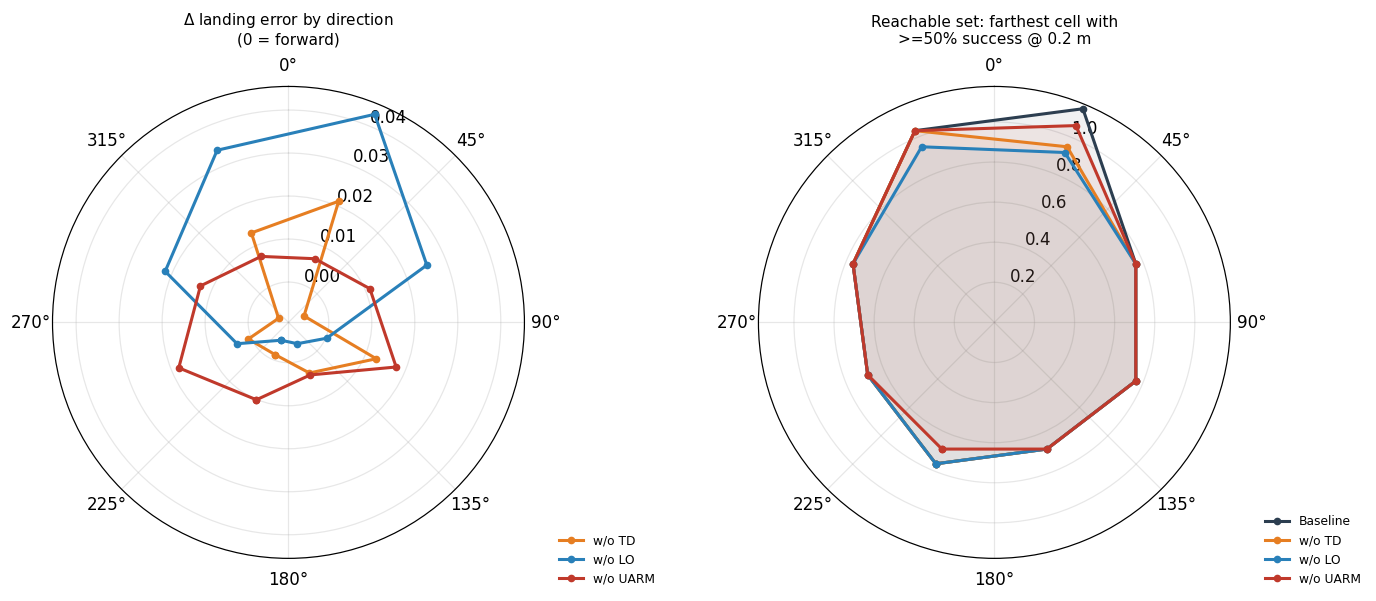

In [46]:
# directional view: gap by sector, and the reachable set per policy
fig = plt.figure(figsize=(13, 5.6))

ax = fig.add_subplot(121, projection="polar")
a_edges = np.linspace(-np.pi, np.pi, 9)
a_c = 0.5 * (a_edges[:-1] + a_edges[1:])
for n in abl_present:
    d = CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values
    ys = [np.nanmean(d[valid_cells[(cang[valid_cells] >= a) & (cang[valid_cells] < b)]])
          for a, b in zip(a_edges[:-1], a_edges[1:])]
    th = np.append(a_c, a_c[0]); rr = np.append(ys, ys[0])
    ax.plot(th, rr, "-o", ms=4, color=exps[n].color, lw=2, label=exps[n].label)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title("$\\Delta$ landing error by direction\n(0 = forward)", va="bottom", fontsize=10)
ax.legend(loc="lower right", bbox_to_anchor=(1.3, -0.08), fontsize=8)

ax = fig.add_subplot(122, projection="polar")
for n, e in exps.items():
    ys = []
    for a, b in zip(a_edges[:-1], a_edges[1:]):
        sel = valid_cells[(cang[valid_cells] >= a) & (cang[valid_cells] < b)]
        good = sel[CELL["succ_loose"][n].values[sel] >= 50.0]
        ys.append(cdist[good].max() if len(good) else 0.0)
    th = np.append(a_c, a_c[0]); rr = np.append(ys, ys[0])
    ax.plot(th, rr, "-o", ms=4, color=e.color, lw=2, label=e.label)
    ax.fill(th, rr, color=e.color, alpha=0.07)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_title(f"Reachable set: farthest cell with\n>=50% success @ {SUCC_LOOSE} m",
             va="bottom", fontsize=10)
ax.legend(loc="lower right", bbox_to_anchor=(1.3, -0.08), fontsize=8)

fig.tight_layout()
savefig(fig, "directional_cells")
plt.show()

## 8. Distributions

Pooled ECDFs are only comparable if the runs sampled the workspace the same way. The dashed curves
below are **cell-reweighted**: each sample is weighted by 1/(number of samples that run has in that
cell), so every cell contributes equally for every policy. Divergence between the solid and dashed
curve of the same colour is exactly the sampling confound.

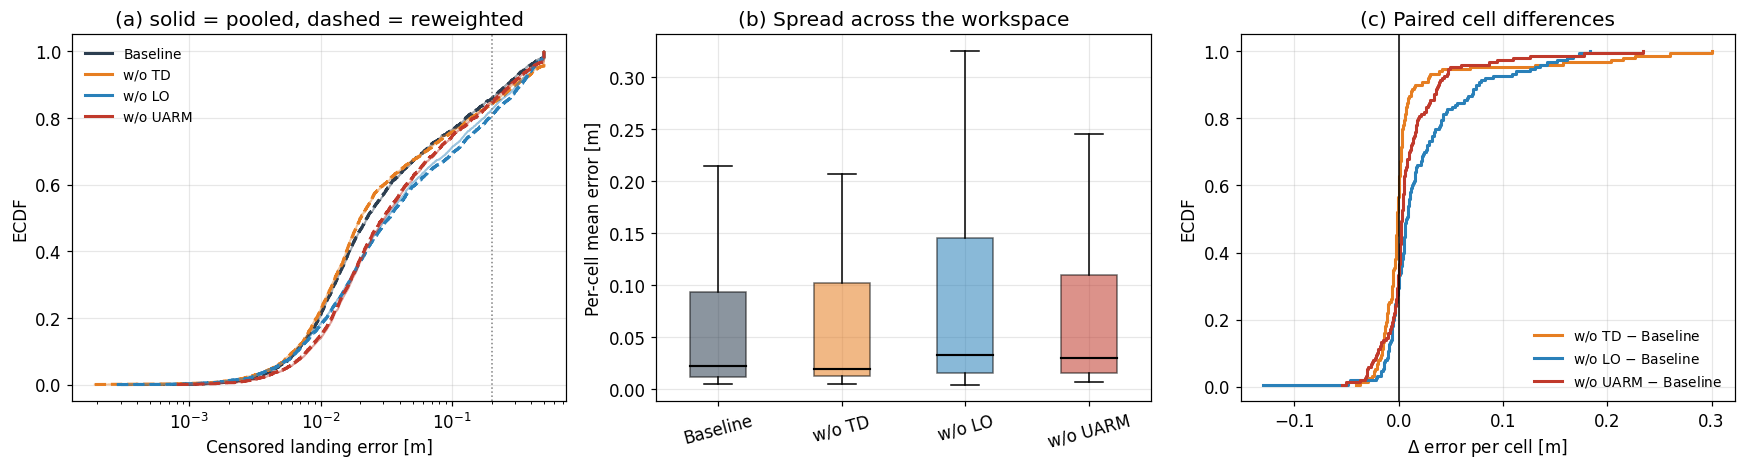

In [47]:
def cell_weights(e):
    cnt = np.bincount(e.cell, minlength=part.n_cells).astype(float)
    w = np.where(VALID[e.cell], 1.0 / np.maximum(cnt[e.cell], 1), 0.0)
    return w


fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
for n, e in exps.items():
    ax.plot([], [], color=e.color, lw=2, label=e.label)
    ecdf(ax, e.pos_err_pen, color=e.color, lw=1.2, alpha=0.45)
    ecdf(ax, e.pos_err_pen, w=cell_weights(e), color=e.color, lw=2, ls="--")
ax.axvline(SUCC_LOOSE, color="grey", ls=":", lw=1)
ax.set_xscale("log"); ax.set_xlabel("Censored landing error [m]")
ax.set_ylabel("ECDF"); ax.set_title("(a) solid = pooled, dashed = reweighted"); ax.legend(fontsize=9)

ax = axes[1]
styled_boxplot(ax, [CELL["pos_err_pen"].loc[valid_cells, n].values for n in exps],
               [e.label for e in exps.values()], [e.color for e in exps.values()])
ax.set_ylabel("Per-cell mean error [m]")
ax.set_title("(b) Spread across the workspace")
ax.tick_params(axis="x", rotation=15)

ax = axes[2]
for n in abl_present:
    d = (CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    ecdf(ax, d[np.isfinite(d)], color=exps[n].color, lw=2, label=f"{exps[n].label} $-$ Baseline")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("$\\Delta$ error per cell [m]"); ax.set_ylabel("ECDF")
ax.set_title("(c) Paired cell differences"); ax.legend(fontsize=9)

fig.tight_layout()
savefig(fig, "distributions_cells")
plt.show()

## 9. Failures

Jeffreys 95% intervals, with the boundary convention that fixes `k = 0` (a zero-failure policy has a
one-sided interval — report its **upper bound**, not "0%").

w/o LO: no failures in 4096 jumps -> report as '<0.061% (95% upper bound)'


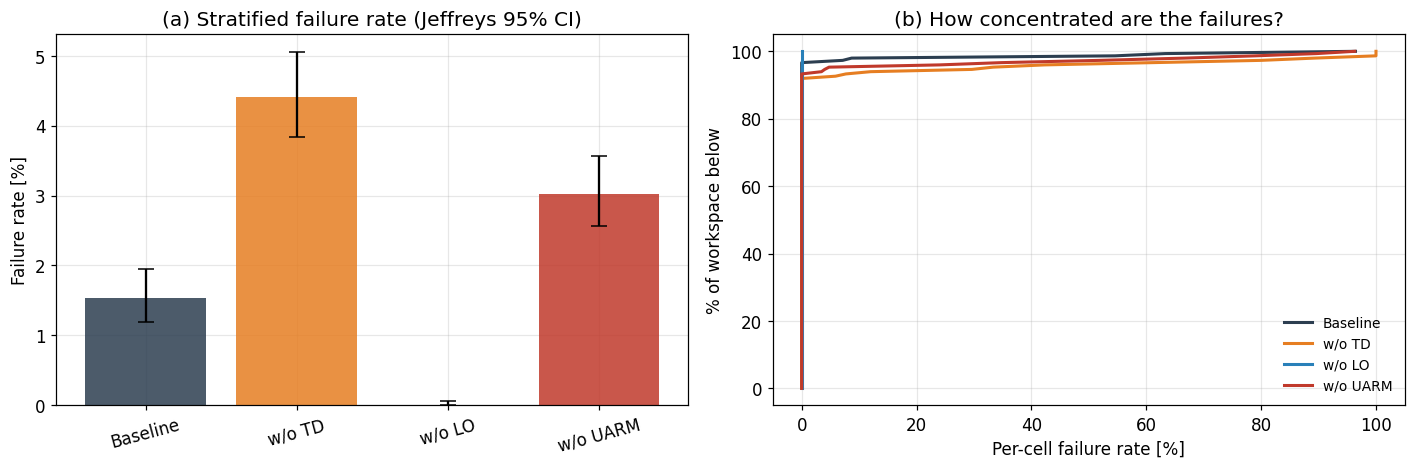

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
labels, rates, elo, ehi, cols = [], [], [], [], []
for n, e in exps.items():
    # stratified failure rate + Jeffreys CI on the pooled counts
    k, nn = int(e.fail.sum()), e.n
    p = k / nn
    lo, hi = stats.beta.ppf([0.025, 0.975], k + 0.5, nn - k + 0.5)
    if k == 0:
        lo = 0.0
    if k == nn:
        hi = 1.0
    labels.append(e.label)
    rates.append(strat("fail", n))
    elo.append(100 * max(p - lo, 0.0)); ehi.append(100 * max(hi - p, 0.0))
    cols.append(e.color)
    if k == 0:
        print(f"{e.label}: no failures in {nn} jumps -> report as '<{100*hi:.3f}% (95% upper bound)'")
ax.bar(labels, rates, yerr=[elo, ehi], color=cols, alpha=0.85, capsize=5)
ax.set_ylabel("Failure rate [%]")
ax.set_title("(a) Stratified failure rate (Jeffreys 95% CI)")
ax.tick_params(axis="x", rotation=15)

ax = axes[1]
for n, e in exps.items():
    v = CELL["fail"][n].values[valid_cells]
    ax.plot(np.sort(v), np.linspace(0, 100, len(v)), color=e.color, lw=2, label=e.label)
ax.set_xlabel("Per-cell failure rate [%]"); ax.set_ylabel("% of workspace below")
ax.set_title("(b) How concentrated are the failures?"); ax.legend(fontsize=9)

fig.tight_layout()
savefig(fig, "failure_cells")
plt.show()

## 10. Mechanism tests

The mechanism claims are now testable at cell level: if removing the touchdown penalty hurts
*through* the bounce channel, then the cells where bounce grew most should be the cells where the
landing error grew most. Same logic for the lift-off penalty. This is the correlation that was
meaningless under index pairing.

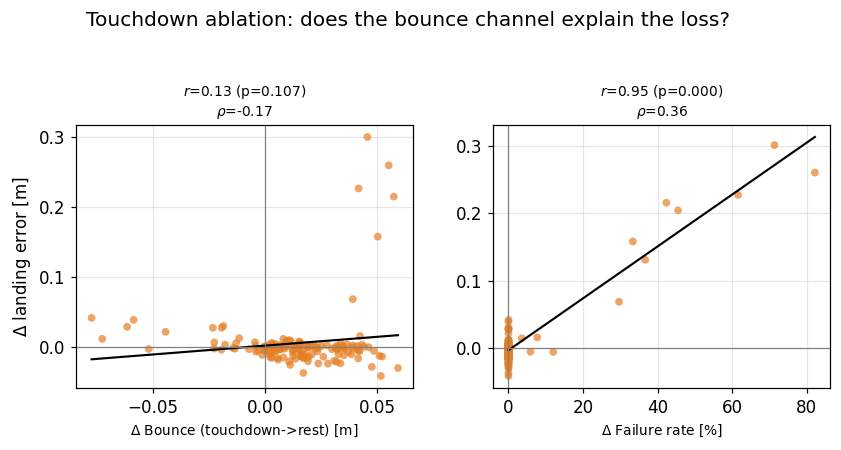

,mechanism,pearson r,p,spearman rho,n cells
0,Bounce (touchdown->rest),0.1335,0.1071,-0.1699,147
1,Failure rate,0.9497,0.0000,0.3640,150


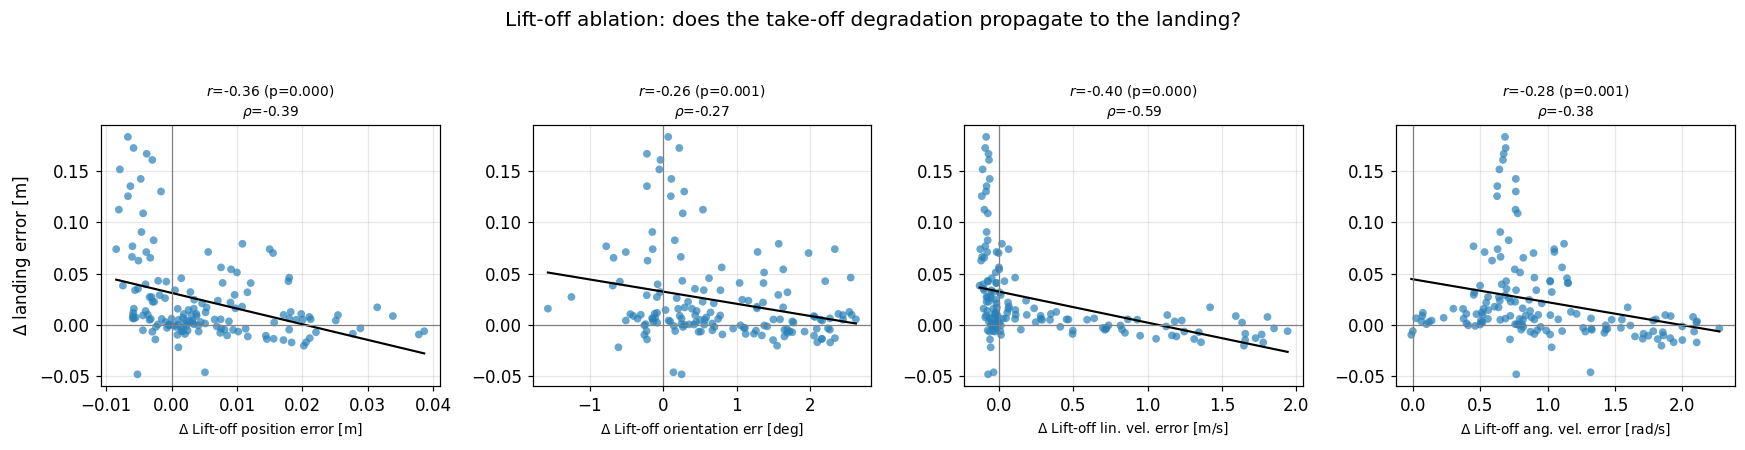

,mechanism,pearson r,p,spearman rho,n cells
0,Lift-off position error,-0.3612,0.0000,-0.3920,149
1,Lift-off orientation err,-0.2611,0.0013,-0.2745,149
2,Lift-off lin. vel. error,-0.4022,0.0000,-0.5862,149
3,Lift-off ang. vel. error,-0.2770,0.0006,-0.3788,149


In [49]:
def mechanism_scatter(abl_name, mech_attrs, fname, title):
    if abl_name not in exps:
        return
    e = exps[abl_name]
    mech_attrs = [a for a in mech_attrs if np.isfinite(CELL[a][abl_name].values[valid_cells]).any()]
    if not mech_attrs:
        print("no mechanism metric available for", abl_name)
        return
    d_err = (CELL["pos_err_pen"][abl_name].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]

    fig, axes = plt.subplots(1, len(mech_attrs), figsize=(4.0 * len(mech_attrs), 3.9))
    axes = np.atleast_1d(axes)
    out = []
    for ax, attr in zip(axes, mech_attrs):
        d_m = (CELL[attr][abl_name].values - CELL[attr][BASELINE].values)[valid_cells]
        m = np.isfinite(d_m) & np.isfinite(d_err)
        r = stats.pearsonr(d_m[m], d_err[m])
        rho = stats.spearmanr(d_m[m], d_err[m])
        ax.scatter(d_m[m], d_err[m], s=26, color=e.color, alpha=0.7, edgecolors="none")
        if m.sum() > 3:
            sl, ic = np.polyfit(d_m[m], d_err[m], 1)
            xs = np.linspace(d_m[m].min(), d_m[m].max(), 10)
            ax.plot(xs, sl * xs + ic, color="black", lw=1.4)
        ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
        ax.set_xlabel(f"$\\Delta$ {MNAME[attr]} [{MUNIT[attr]}]", fontsize=9)
        ax.set_title(f"$r$={r.statistic:.2f} (p={r.pvalue:.3f})\n$\\rho$={rho.statistic:.2f}",
                     fontsize=9)
        out.append({"mechanism": MNAME[attr], "pearson r": r.statistic, "p": r.pvalue,
                    "spearman rho": rho.statistic, "n cells": int(m.sum())})
    axes[0].set_ylabel("$\\Delta$ landing error [m]")
    fig.suptitle(title, y=1.04)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()
    display(pd.DataFrame(out).round(4))


mechanism_scatter("no_bounce_angular_touchdown", ["bounce", "fail"],
                  "mechanism_touchdown",
                  "Touchdown ablation: does the bounce channel explain the loss?")

mechanism_scatter("no_liftoof_disc_penalty",
                  ["lo_pos", "lo_orient", "lo_vel", "lo_ang_vel"],
                  "mechanism_liftoff",
                  "Lift-off ablation: does the take-off degradation propagate to the landing?")

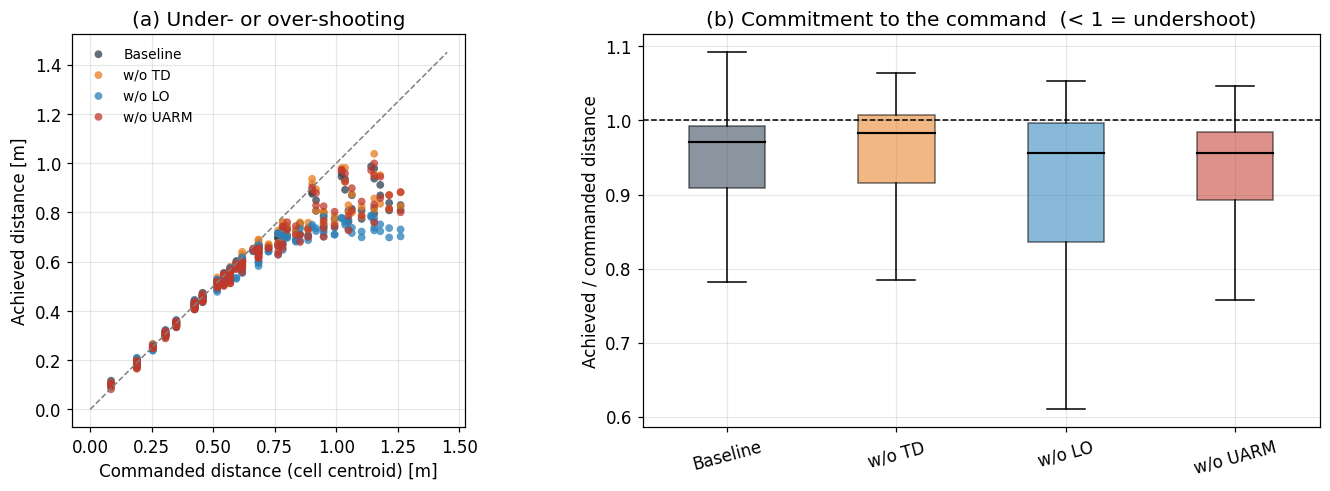

In [50]:
# is a zero-failure / low-error policy actually just being conservative?
# compare achieved vs commanded distance per cell -- an under-committed policy undershoots.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for n, e in exps.items():
    ach = np.array([np.nanmean(e.actual_dist[(e.cell == c) & e.ok]) if ((e.cell == c) & e.ok).sum() >= 3
                    else np.nan for c in range(part.n_cells)])
    ax.scatter(cdist[valid_cells], ach[valid_cells], s=26, color=e.color, alpha=0.75,
               edgecolors="none", label=e.label)
lim = np.nanmax(cdist[valid_cells]) * 1.15
ax.plot([0, lim], [0, lim], "--", color="grey", lw=1)
ax.set_xlabel("Commanded distance (cell centroid) [m]")
ax.set_ylabel("Achieved distance [m]")
ax.set_title("(a) Under- or over-shooting"); ax.legend(fontsize=9)
ax.set_aspect("equal", "box")

ax = axes[1]
labels, ratios = [], []
for n, e in exps.items():
    r = np.array([np.nanmean(e.actual_dist[(e.cell == c) & e.ok] / np.maximum(e.des_dist[(e.cell == c) & e.ok], 1e-6))
                  if ((e.cell == c) & e.ok).sum() >= 3 else np.nan for c in range(part.n_cells)])
    labels.append(e.label); ratios.append(r[valid_cells][np.isfinite(r[valid_cells])])
styled_boxplot(ax, ratios, labels, [e.color for e in exps.values()])
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_ylabel("Achieved / commanded distance")
ax.set_title("(b) Commitment to the command  (< 1 = undershoot)")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
savefig(fig, "commitment_check")
plt.show()

## 11. Robustness check — nearest-neighbour matching

An independent route to the same comparison: match every baseline target to the closest ablation
target within `MATCH_RADIUS`, one-to-one. This gives true sample pairs at the cost of a small
mismatch in the commanded target. If it agrees with the cell-level result, the conclusion is not an
artifact of the binning choice.

In [51]:
MATCH_RADIUS = 0.05      # [m] maximum allowed mismatch between paired commands


def nn_match(a, b, radius=MATCH_RADIUS):
    # greedy one-to-one match of a's targets to b's targets within radius
    tree = cKDTree(b.des_pos)
    dist, idx = tree.query(a.des_pos, k=1, distance_upper_bound=radius)
    ok = np.isfinite(dist)
    order = np.argsort(np.where(ok, dist, np.inf))
    used, pa, pb = set(), [], []
    for i in order:
        if not ok[i]:
            break
        j = idx[i]
        if j in used:
            continue
        used.add(j); pa.append(i); pb.append(j)
    return np.array(pa, int), np.array(pb, int), dist[np.array(pa, int)] if pa else np.array([])


rows = []
for n in abl_present:
    e = exps[n]
    ia, ib, dd = nn_match(base, e)
    if len(ia) < 30:
        rows.append({"Ablation": e.label, "matched pairs": len(ia), "note": "too few matches"})
        continue
    x, y = base.pos_err_pen[ia], e.pos_err_pen[ib]
    d = y - x
    try:
        p = stats.wilcoxon(x, y).pvalue
    except ValueError:
        p = 1.0
    lo, hi = cluster_bootstrap_ci(d)
    rows.append({
        "Ablation": e.label, "matched pairs": len(ia),
        "match radius mean [m]": float(dd.mean()),
        "matched frac of baseline [%]": 100 * len(ia) / base.n,
        "diff [m]": float(d.mean()), "CI lo": lo, "CI hi": hi,
        "p": p, "sig": stars(p),
    })
match_df = pd.DataFrame(rows)
print(f"NN matching within {MATCH_RADIUS} m — compare 'diff' against the cell-level 'diff' above")
match_df.round(4)

NN matching within 0.05 m — compare 'diff' against the cell-level 'diff' above


,Ablation,matched pairs,match radius mean [m],matched frac of baseline [%],diff [m],CI lo,CI hi,p,sig
0,w/o TD,2398,0.0096,58.5449,0.0077,0.0050,0.0106,0.0,***
1,w/o LO,2371,0.0096,57.8857,0.0223,0.0200,0.0244,0.0,***
2,w/o UARM,2369,0.0094,57.8369,0.0086,0.0064,0.0108,0.0,***


## 12. Composite paper figure

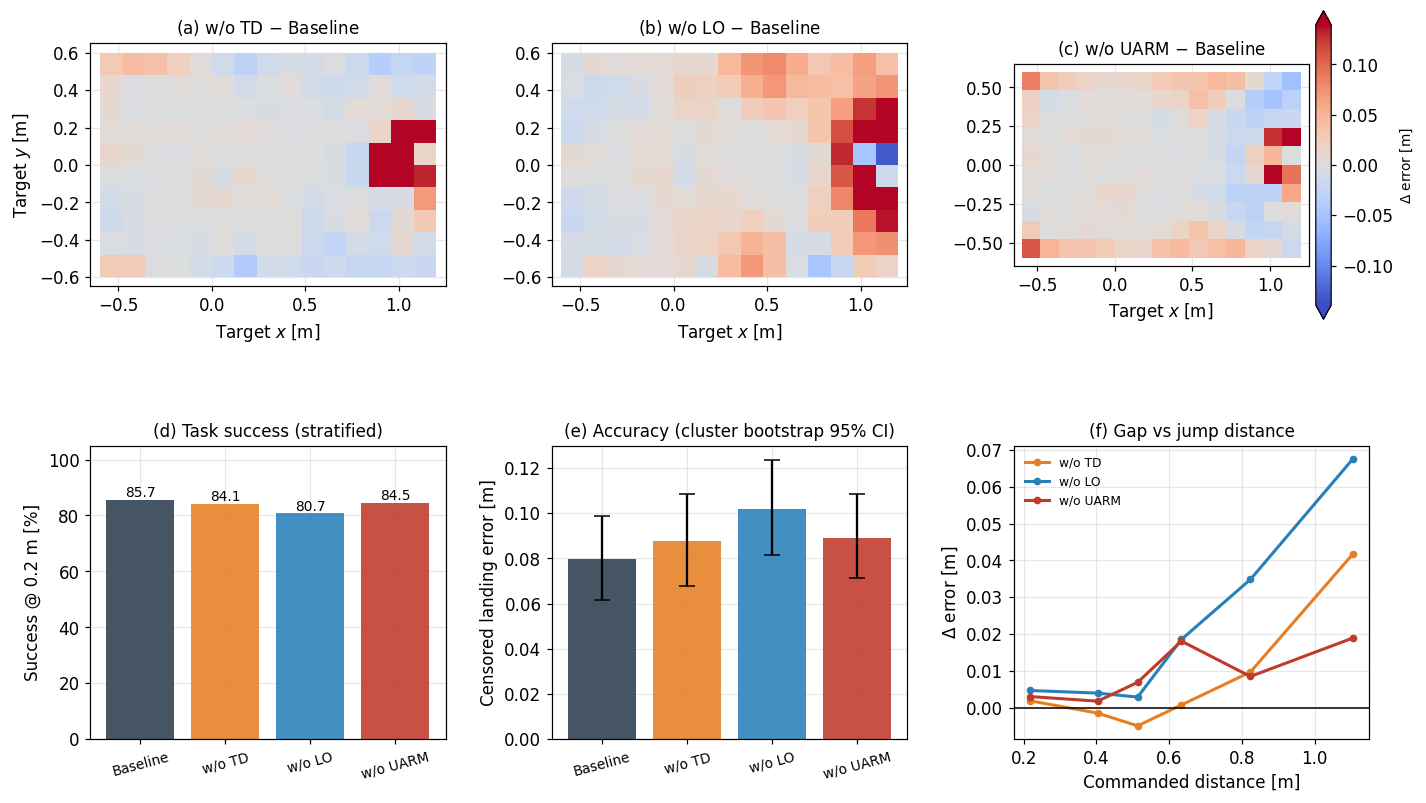

In [52]:
fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.05, 1.0], hspace=0.42, wspace=0.30)

d_all = [CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values for n in abl_present]
lim = np.nanpercentile(np.abs(np.concatenate(d_all)), 97)
norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

for i, (n, d) in enumerate(zip(abl_present[:3], d_all[:3])):
    ax = fig.add_subplot(gs[0, i])
    dd_ = d.copy(); dd_[~VALID] = np.nan
    m = part.plot(ax, dd_, cmap="coolwarm", norm=norm)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_title(f"({chr(97+i)}) {exps[n].label} $-$ Baseline", fontsize=11)
    ax.set_xlabel("Target $x$ [m]")
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    if i == len(abl_present[:3]) - 1:
        cb = fig.colorbar(m, ax=ax, pad=0.02, extend="both")
        cb.set_label("$\\Delta$ error [m]", fontsize=9)

labs = [e.label for e in exps.values()]
cols = [e.color for e in exps.values()]

ax = fig.add_subplot(gs[1, 0])
vals = [strat("succ_loose", n) for n in exps]
ax.bar(labs, vals, color=cols, alpha=0.88)
for i, v in enumerate(vals):
    ax.text(i, v + 1.0, f"{v:.1f}", ha="center", fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel(f"Success @ {SUCC_LOOSE} m [%]")
ax.set_title("(d) Task success (stratified)", fontsize=11)
ax.tick_params(axis="x", rotation=15, labelsize=9)

ax = fig.add_subplot(gs[1, 1])
means, elo2, ehi2 = [], [], []
for n in exps:
    v = CELL["pos_err_pen"].loc[valid_cells, n].values
    mu = np.nanmean(v)
    lo, hi = cluster_bootstrap_ci(v, n_boot=4000)
    means.append(mu); elo2.append(max(mu - lo, 0)); ehi2.append(max(hi - mu, 0))
ax.bar(labs, means, yerr=[elo2, ehi2], color=cols, alpha=0.88, capsize=5)
ax.set_ylabel("Censored landing error [m]")
ax.set_title("(e) Accuracy (cluster bootstrap 95% CI)", fontsize=11)
ax.tick_params(axis="x", rotation=15, labelsize=9)

ax = fig.add_subplot(gs[1, 2])
for n in abl_present:
    d = CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values
    ys = [np.nanmean(d[valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]])
          for a, b in zip(r_edges[:-1], r_edges[1:])]
    ax.plot(r_c, ys, "-o", ms=4, color=exps[n].color, lw=2, label=exps[n].label)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Commanded distance [m]"); ax.set_ylabel("$\\Delta$ error [m]")
ax.set_title("(f) Gap vs jump distance", fontsize=11)
ax.legend(fontsize=8)

savefig(fig, "ablation_paper_figure")
plt.show()

## 13. Report

In [53]:
def fmt_p(p):
    return "< 0.001" if p < 1e-3 else f"= {p:.3f}"


L = []
L.append(f"# Reward ablation report — Unitree {robot}, omnidirectional jumps on flat terrain")
L.append("")
L.append("## Method")
L.append("")
L.append(f"- Targets are randomly sampled independently per run, so comparisons are made over a "
         f"shared **{PARTITION_KIND}** partition of the command space "
         f"({part.n_cells} cells, {int(VALID.sum())} usable with >= {MIN_PER_CELL} samples per run).")
L.append(f"- Aggregates are **stratified** (cells weighted equally); CIs are cluster bootstraps over cells; "
         f"significance is Wilcoxon signed-rank over cells with Holm correction across {len(stats_df)} tests.")
L.append(f"- Headline accuracy is the **censored** error (failures set to {PEN_CAP} m), which is free of "
         f"the selection bias that makes a failure-prone policy look accurate.")
L.append("")
L.append("## Headline numbers (stratified)")
L.append("")
hd = summary[["Policy", mlabel("pos_err_pen"), mlabel("pos_err"), mlabel("fail"),
              mlabel("succ_loose"), mlabel("bounce")]]
L.append(as_markdown(hd))
L.append("")

for n in abl_present:
    e = exps[n]
    L.append(f"## {e.label} — {e.long_label}")
    L.append("")
    sub = stats_df[stats_df["Ablation"] == e.label].set_index("attr")

    if "pos_err_pen" in sub.index:
        r = sub.loc["pos_err_pen"]
        verb = "degrades" if r["diff"] > 0 else "improves"
        L.append(f"- **Accuracy (censored)**: {r['baseline']:.4f} -> {r['ablation']:.4f} m "
                 f"({r['diff']:+.4f} m, {r['rel [%]']:+.1f}%; 95% CI [{r['CI lo']:+.4f}, {r['CI hi']:+.4f}]; "
                 f"worse in {r['cells worse [%]']:.0f}% of the workspace; p {fmt_p(r['p_holm'])} {r['sig']}; "
                 f"Cliff's d = {r['cliff d']:+.3f}, {r['effect']}). Removing this term **{verb}** accuracy.")
    if "pos_err" in sub.index:
        r = sub.loc["pos_err"]
        L.append(f"- Accuracy over successful jumps only: {r['baseline']:.4f} -> {r['ablation']:.4f} m "
                 f"({r['rel [%]']:+.1f}%). Compare with the censored number above: a gap between the two "
                 f"means the difference is partly survivorship.")
    for attr in ("fail", "succ_loose"):
        if attr in sub.index:
            r = sub.loc[attr]
            L.append(f"- {MNAME[attr]}: {r['baseline']:.2f}% -> {r['ablation']:.2f}% "
                     f"({r['diff']:+.2f} pp, p {fmt_p(r['p_holm'])} {r['sig']}).")
    for attr in ("bounce", "lo_pos", "lo_orient", "lo_vel", "lo_ang_vel", "yaw_err"):
        if attr in sub.index:
            r = sub.loc[attr]
            L.append(f"- {MNAME[attr]}: {r['baseline']:.4f} -> {r['ablation']:.4f} {MUNIT[attr]} "
                     f"({r['rel [%]']:+.1f}%, p {fmt_p(r['p_holm'])} {r['sig']}, {r['effect']}).")
    if e.label in dist_dep.index:
        dd = dist_dep.loc[e.label]
        L.append(f"- Distance dependence: gap {dd['gap near [m]']:+.4f} m on near cells vs "
                 f"{dd['gap far [m]']:+.4f} m on far cells; slope "
                 f"{dd['slope [m error / m distance]']:+.4f} m/m, Spearman rho "
                 f"{dd['Spearman rho']:+.2f} (p {fmt_p(dd['p'])}).")
    L.append("")

L.append("## Caveats")
L.append("")
L.append("- Cell-level pairing removes the target-sampling confound but assumes performance is "
         "roughly homogeneous inside a cell. Re-run with a finer partition to confirm the "
         "conclusions are not sensitive to the binning.")
L.append("- Single training seed per condition: p-values quantify variation across the workspace, "
         "not across training runs. State this in the paper, or train >= 3 seeds per ablation.")
L.append("- Mechanism correlations are associational.")

report = "\n".join(L)
with open(osp.join(FIG_DIR, "ablation_report.md"), "w") as fh:
    fh.write(report)
print(report)

# Reward ablation report — Unitree go1, omnidirectional jumps on flat terrain

## Method

- Targets are randomly sampled independently per run, so comparisons are made over a shared **grid** partition of the command space (150 cells, 150 usable with >= 10 samples per run).
- Aggregates are **stratified** (cells weighted equally); CIs are cluster bootstraps over cells; significance is Wilcoxon signed-rank over cells with Holm correction across 36 tests.
- Headline accuracy is the **censored** error (failures set to 0.5 m), which is free of the selection bias that makes a failure-prone policy look accurate.

## Headline numbers (stratified)

  Policy  Landing error (censored) [m]  Landing error | success [m]  Failure rate [%]  Success @ 0.2 m [%]  Bounce (touchdown->rest) [m]
Baseline                      0.079646                     0.073429          1.534306            85.674924                      0.157898
  w/o TD                      0.087574                     0.068831          4

In [54]:
print("outputs in:", FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

outputs in: /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation/figures_ablation
   ablation_cell_stats.csv
   ablation_fingerprint.pdf
   ablation_fingerprint.png
   ablation_headline.tex
   ablation_paired_stats.csv
   ablation_paper_figure.pdf
   ablation_paper_figure.png
   ablation_primary_stats.tex
   ablation_report.md
   ablation_summary.csv
   ablation_summary.tex
   bounce_analysis.pdf
   bounce_analysis.png
   bounce_mechanism.pdf
   bounce_mechanism.png
   cellmap_delta_error.pdf
   cellmap_delta_error.png
   cellmap_delta_failure.pdf
   cellmap_delta_failure.png
   cellmap_error.pdf
   cellmap_error.png
   commitment_check.pdf
   commitment_check.png
   directional_cells.pdf
   directional_cells.png
   distance_tracking.pdf
   distance_tracking.png
   distributions_cells.pdf
   distributions_cells.png
   error_distributions.pdf
   error_distributions.png
   failure_analysis.pdf
   failure_analysis.png
   failure_cells.pdf
   failure_cells.png
   l